# Getting Started

The Artificial Benchmark for Community Detection (ABCD) is a method for sampling a random graph with known ground truth community structure. Real data with reliable ground truth is scarce, and sharing these datasets can be difficult due to privacy concerns, for example, financial networks. In contrast, we can easily sample and share any number of synthetic graphs (with trusted ground truth communities), and use these networks as a proxy to build and test our algorithms.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from abcd_graph import ABCD, ABCDSample

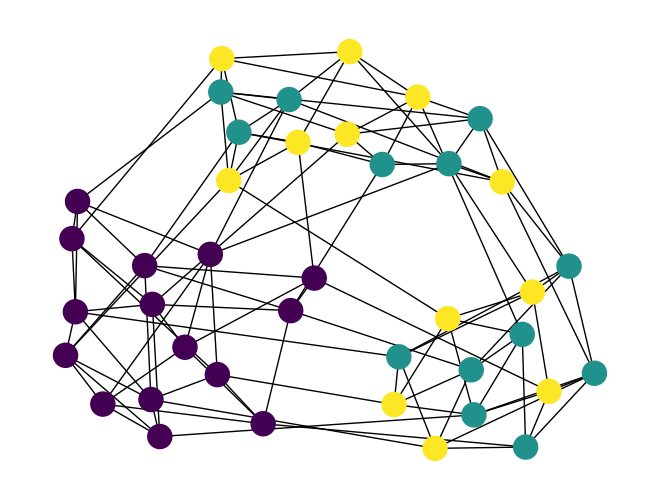

In [2]:
abcd = ABCD(40, min_community_size=10, rng=np.random.default_rng(seed=42))
graph = abcd.sample()

G = graph.to_networkx()
pos = nx.forceatlas2_layout(G, seed=42)
nx.draw(G, pos=pos, node_color=graph.community_array)

## Key Parameters

There are only two essential parameters for ABCD graphs: the number of vertices (n) and the level of noise (xi). The level of noise is a number between 0 and 1 that controls the proportion of edges that are wired without looking at the community structure. When xi is 0, all edges will be intra-community, so the communities will be disjoint. On the other end, when xi is 1, the graph will be completely random and have no signature of the ground truth communities.

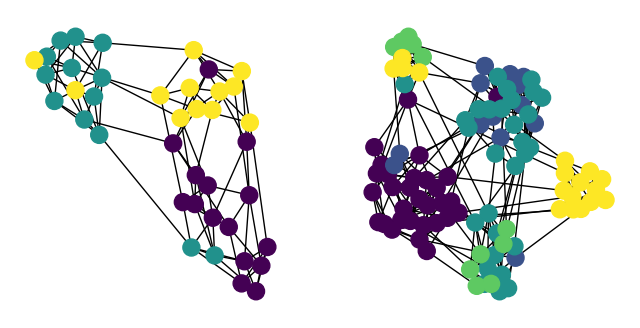

In [3]:
# The default minimum community size is 20, but we decrease to 10
# for these small examples so that we get more than 2 communities.
abcd = ABCD(40, xi=0.1, min_community_size=10, rng=np.random.default_rng(seed=42))
graph1 = abcd.sample()

abcd.n = 100
graph2 = abcd.sample()

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

G1 = graph1.to_networkx()
pos = nx.forceatlas2_layout(G1, seed=42)  # for a reproducible layout
nx.draw(G1, ax=axs[0], pos=pos, node_size=150, node_color=graph1.community_array)

G2 = graph2.to_networkx()
pos = nx.forceatlas2_layout(G2, seed=42)  # for a reproducible layout
nx.draw(G2, ax=axs[1], pos=pos, node_size=150, node_color=graph2.community_array)

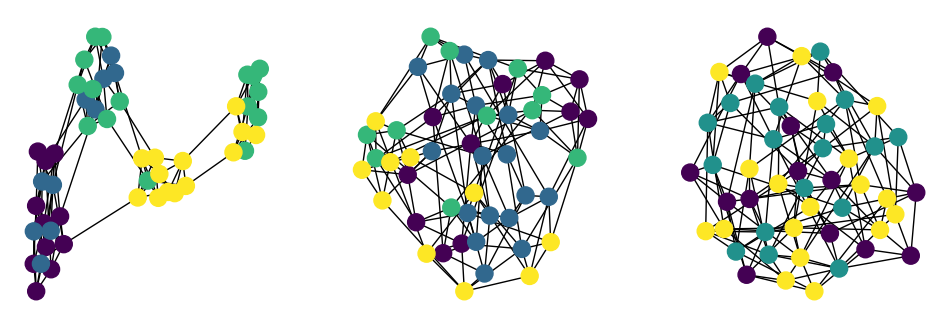

In [4]:
# Sample three ABCD graph with increasing level of noise.
abcd = ABCD(50, xi=0.1, min_community_size=10, rng=np.random.default_rng(seed=42))
low_noise = abcd.sample()

abcd.xi = 0.3
med_noise = abcd.sample()

abcd.xi = 0.6
high_noise = abcd.sample()

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=100)
for i, graph in enumerate([low_noise, med_noise, high_noise]):
    G = graph.to_networkx()
    pos = nx.forceatlas2_layout(G, seed=42)  # for a reproducible layout
    nx.draw(G, ax=axs[i], pos=pos, node_size=150, node_color=graph.community_array)

## Graph Properties

A key property observed in real complex networks is that both the degree and community size distributions tend to follow a powerlaw. That is, the probability of getting a degree/community size of $d$ occurs with probability $d^{-\alpha}$ for some exponent $\alpha > 0$. This means there are a few very large degrees/communities, but most are quite small. Analysis of real graph data has found the degree exponent is typically between 2 and 3, whereas the community size exponent is typically between 1 and 2. The ABCD model samples both degrees and community sizes from discrete powerlaw distributions controlled by the following parameters.

### Degrees
- minimum_degree
- maximum_degree
- degree_exponent

### Community Sizes
- minimum_community_size
- maximum_community_size
- community_size_exponent

We can plot the expected vs empirical degree and community size distributions to check that they are being sampled correctly. Plots usually plot the inverse cumulative distribution function (icdf) on the y-axis and
use log-log scaling. In an ideal sample and large range, the plot will show a straight line with slope equal
to the exponent of the powerlaw, but due to the bounded range it tends to have a slightly concave shape.

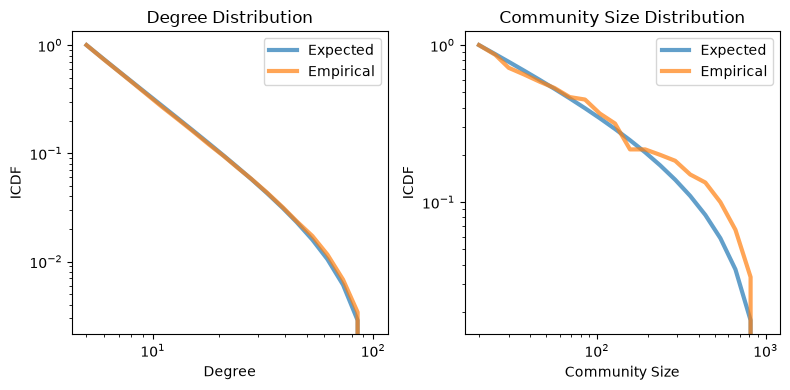

In [5]:
abcd = ABCD(
    10000,  # it's helpful to increase the nodes so we sample more degrees and communities
    min_degree=5,
    max_degree=100,
    degree_exponent=2.5,
    min_community_size=20,
    max_community_size=1000,
    community_size_exponent=1.5,
    rng=np.random.default_rng(seed=42),
)

graph = abcd.sample()

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=100)

# Plot at integers evenly spaced on a log scale
points = np.round(np.geomspace(5, 100, 20)).astype(int)
expected = abcd.expected_degree_icdf(points)
axs[0].plot(points, expected, label="Expected", alpha=0.7, lw=3)
empirical = graph.degree_icdf(points)
axs[0].plot(points, empirical, label="Empirical", alpha=0.7, lw=3)
axs[0].legend()
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_ylabel("ICDF")
axs[0].set_xlabel("Degree")
axs[0].set_title("Degree Distribution")

# Plot at integers evenly spaced on a log scale
points = np.round(np.geomspace(20, 1000, 20)).astype(int)
expected = abcd.expected_community_size_icdf(points)
axs[1].plot(points, expected, label="Expected", alpha=0.7, lw=3)
empirical = graph.community_size_icdf(points)
axs[1].plot(points, empirical, label="Empirical", alpha=0.7, lw=3)
axs[1].legend()
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_ylabel("ICDF")
axs[1].set_xlabel("Community Size")
axs[1].set_title("Community Size Distribution")

fig.tight_layout()

## Fitting ABCD Parameters to your data

If you do happen to have a graph and want to test how your algorithm performs in general under similar conditions, or you want to see how changing one aspect of the graph changes the algorithms performance, you can fit an ABCD object to match the empirical parameters of an ABCDSample. This means all you have to do is pass an edge list and community array / membership matrix to ABCDSample and call ABCD.fit(). The parameters available to be set are
- n
- xi
- outliers
- eta
- rho
- degree_exponent
- min_degree
- max_degree
- community_size_exponent
- min_community_size
- max_community_size
- degree_sequence
- community_size_sequence

By default, all parameters except degree_sequence and community_size_sequence are set to match the empirical values seen in the ABCDSample, but you can pass a list of parameters to fit() that will not be set.

As an example, lets load the football graph studied by [Girvan and Newman (2002)](https://doi.org/10.1073/pnas.122653799). This graph has 115 vertices representing american football teams, where each conference is treated as a community.

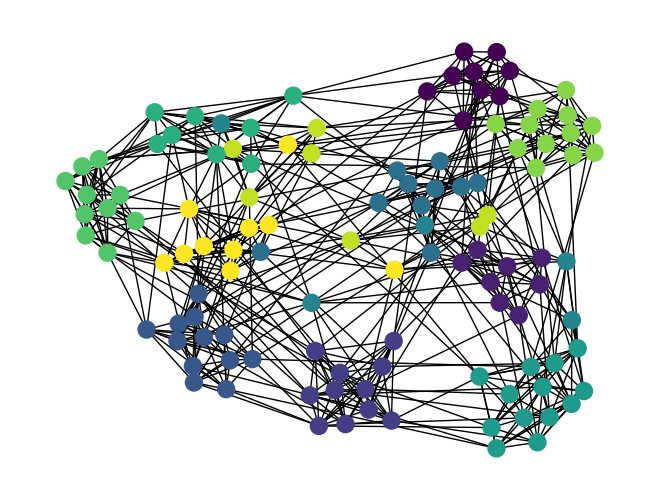

In [6]:
import io
import urllib.request
import zipfile

# Request the football dataset and read as a networkx object
url = "http://www-personal.umich.edu/~mejn/netdata/football.zip"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
sock = urllib.request.urlopen(req)
s = io.BytesIO(sock.read())
sock.close()

zf = zipfile.ZipFile(s)
txt = zf.read("football.txt").decode()
gml = zf.read("football.gml").decode()
gml = gml.split("\n")[1:]
G = nx.parse_gml(gml)

pos = nx.forceatlas2_layout(G, seed=42)  # for a reproducible layout
colors = [G.nodes[n]["value"] for n in G.nodes]
nx.draw(G, pos=pos, node_size=150, node_color=colors)

/Users/ryandewolfe/miniforge3/envs/abcd/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Users/ryandewolfe/miniforge3/envs/abcd/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Users/ryandewolfe/Research/abcd-graph/abcd_graph/abcd.py:422: UserWarning: Typical degree exponents are between 1 and 2, got 2.39348027429513
  self._validate_params()


ABCD object parameters now match those in the fitted graph
n 115
xi 0.3572593800978793
outliers 0
eta 1.0
dimension 8
rho 1.0
degree_exponent 2.999999999999999
min_degree 7
max_degree 12
community_size_exponent 2.39348027429513
min_community_size 5
max_community_size 13
degree_sequence None
community_size_sequence None
alpha_max 60.0
alpha_min -60.0
alpha_iters 10
rho_tol 0.05
model configuration
max_swap_attempts_per_bad_edge 5
rng Generator(PCG64)
logger None
verbose False


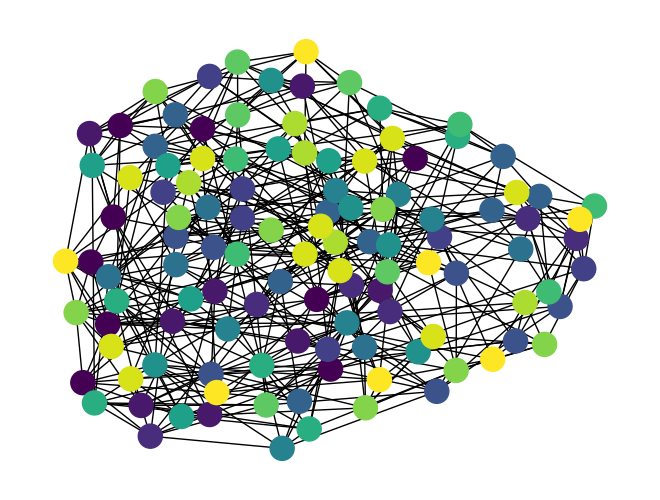

In [7]:
# Convert networkx graph into an ABCDSample
edges = np.array(G.edges())
# Converts node names into ids
names, edges = np.unique(edges, return_inverse=True)
community_dict = nx.get_node_attributes(
    G, "value"
)  # Community ids are stored in an attribute called value
communities = np.array([community_dict[n] for n in names])
graph = ABCDSample(edges, communities)

abcd = ABCD(100, rng=np.random.default_rng(seed=42))
abcd.fit(graph)
print("ABCD object parameters now match those in the fitted graph")
for key, value in vars(abcd).items():
    print(key, value)  # Print a name-value dict of fit parameters

graph = abcd.sample()
G = graph.to_networkx()
pos = nx.forceatlas2_layout(G, seed=42)
nx.draw(G, pos=pos, node_color=graph.community_array)

By default, ABCD objects fits the community and degree sequence by finding a powerlaw distribution that matches the observed value. However, if your graph does not follow a powerlaw, you can let the ABCD graph copy the exact degree and community size sequences. 

ABCD object parameter now match those in the fitted graph
n 115
xi 0.5020576131687242
outliers 0
eta 1.0
dimension 8
rho 1.0
degree_exponent 2.999999999999999
min_degree 7
max_degree 12
community_size_exponent 2.999999999999999
min_community_size 5
max_community_size 11
degree_sequence [ 8 10 10 12  8  9 10  7 10  7  9 11  7  8 11 10  8  8  9  8  8  8  9  9
 10  7  7  9  9  8 10  8  7 10  9  8  7  9  8 10 11 12 11  7 11 11  7  7
  7  7  7  7  8  9  9  8  7  7  7  7  7  7  8  8  7  7  8  8  9  8  8  9
  8  9  7  7  7  7  7  7  7  7  7  7  9  8  8  7 10  8  7 10  7  7  7  7
  7  8 12  8 10  9 10 10 11 10 12  9  8 10 10  9  9  8  9]
community_size_sequence [ 9  8  6  7  7  9  5  6  5  6  6  5  5  8  5 11  7]
alpha_max 60.0
alpha_min -60.0
alpha_iters 10
rho_tol 0.05
model configuration
max_swap_attempts_per_bad_edge 5
rng Generator(PCG64)
logger None
verbose False
logger_ <Logger abcd_graph.abcd (WARNING)>


/Users/ryandewolfe/miniforge3/envs/abcd/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,
/Users/ryandewolfe/miniforge3/envs/abcd/lib/python3.13/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


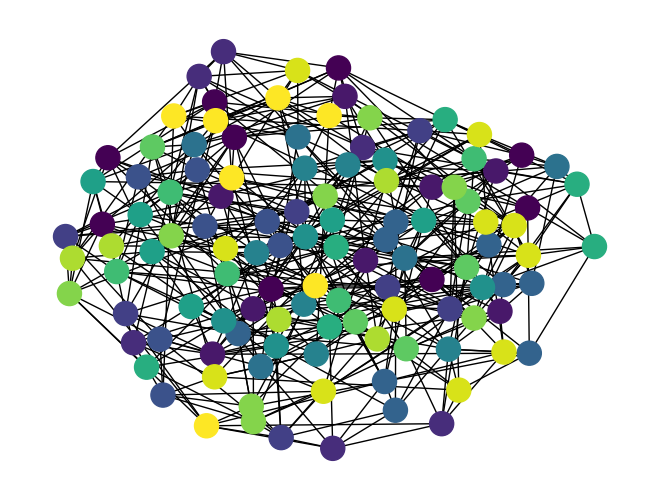

In [8]:
abcd.fit(graph, do_not_set=None)
print("ABCD object parameter now match those in the fitted graph")
for key, value in vars(abcd).items():
    print(key, value)  # Print a name-value dict of fit parameters

graph = abcd.sample()
G = graph.to_networkx()
pos = nx.forceatlas2_layout(G, seed=42)
nx.draw(G, pos=pos, node_color=graph.community_array)

## Comparing to LFR

The ABCD model was built to be a faster version of the very popular LFR model ([Lancichinetti, Fortunato, and Radicchi, 2008](https://doi.org/10.1103/PhysRevE.78.046110)). Both models feature powerlaw degree and community size sequences but diverge in the noise parameter. LFR uses a noise parameter *mu* between 0 and 1 that is the fraction of inter-community edges, appear similar to ABCD's noise parameter xi. However, when mu is large (think 1), there will be so few edges within communities that they become less dense than the overall graph; the communities are actually anti-communities. In contrast, when xi is 1 the graph communities will be exactly as dense as the background graph (because edges are wired randomly), so we never push into anti-communities.

Lets test the speed of both models. We'll use the [LFR implementation available through networkx](https://networkx.org/documentation/stable/reference/generated/networkx.generators.community.LFR_benchmark_graph.html), although we'll note it's slightly different than the model from the LFR paper. We'll also note that our implementation relies on numba which can take extra time to compile on the first run, that's why the second code cell in this notebook takes so long.

In [9]:
from time import perf_counter

# Speed test vs networkx's LFR implementation
min_n = 1000
max_n = 100000
n_ns = 20
reps = 10

ns = np.round(np.geomspace(min_n, max_n, n_ns)).astype(int)
lfr = np.empty((len(ns), reps), dtype="float64")
abcd = np.empty_like(lfr)

for i, n in enumerate(ns):
    for j in range(reps):
        start = perf_counter()
        ABCD(n).sample()
        end = perf_counter()
        abcd[i, j] = end - start

        start = perf_counter()
        nx.LFR_benchmark_graph(
            n,
            2.5,
            1.5,
            0.25,
            min_degree=5,
            max_degree=int(n**0.5),
            min_community=20,
            max_community=int(n**0.75),
            max_iters=10000,
        )
        end = perf_counter()
        lfr[i, j] = end - start

Text(0.5, 1.0, 'Scaling of ABCD and LFR')

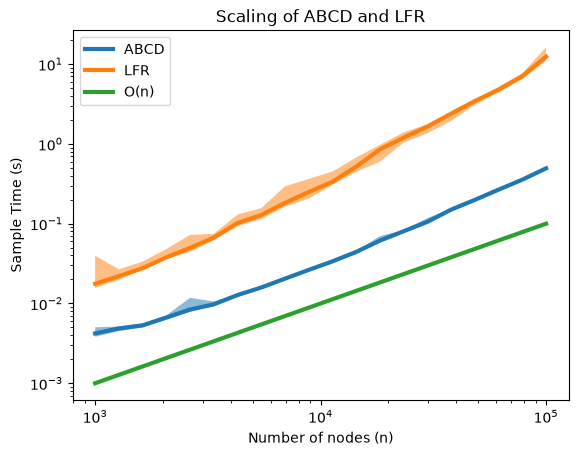

In [10]:
plt.plot(ns, np.median(abcd, axis=1), lw=3, label="ABCD")
plt.fill_between(
    ns, np.quantile(abcd, 0.1, axis=1), np.quantile(abcd, 0.9, axis=1), alpha=0.5
)
plt.plot(ns, np.median(lfr, axis=1), lw=3, label="LFR")
plt.fill_between(
    ns, np.quantile(lfr, 0.1, axis=1), np.quantile(lfr, 0.9, axis=1), alpha=0.5
)

plt.plot(ns, 1e-6 * ns, lw=3, label="O(n)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.ylabel("Sample Time (s)")
plt.xlabel("Number of nodes (n)")
plt.title("Scaling of ABCD and LFR")

Although both model run in O(n), the ABCD implementation runs about one order of magnitude faster. If you wanted to benchmark an algorithm on graphs with 10,000 nodes (10^4), and you needed to generate 1000 graphs, the ABCD model would take 30 seconds while LFR would take 5 minutes.

## What to do next

### Run a benchmark
We have examples of benchmarking community detection algorithms with ABCD using the following libraries:
- [networkx](benchmark_networkx.ipynb); the most popular
- [igraph](benchmark_igraph.ipynb); the most algorithms
- [sknetwork](benchmark_sknetwork.ipynb); the fastest

### Check out the extensions
We have notebooks detailing the extensions to [outliers](outliers.ipynb) and [overlapping](overlap.ipynb) communities.

### Read the papers

Defining the model:

- [Bogumił Kamiński, Paweł Prałat, and François Théberge. Artificial Benchmark for Community Detection (ABCD)—Fast random graph model with community structure. Network Science 9(2):153-178 (2021) doi: 10.1017/nws.2020.45](https://doi.org/10.1017/nws.2020.45)

- [Bogumił Kamiński, Tomasz Olczak, Bartosz Pankratz, Paweł Prałat, and François Théberge. Properties and Performance of the ABCDe Random Graph Model with Community Structure. Big Data Research 30:100348 (2022) doi: 10.1016/j.bdr.2022.100348](https://doi.org/10.1016/j.bdr.2022.100348)

- [Bogumił Kamiński, Paweł Prałat, François Théberge. Artificial benchmark for community detection with outliers (ABCD+o). Applied Network Science 8 (2023) doi: 10.1007/s41109-023-00552-9](https://doi.org/10.1007/s41109-023-00552-9)

- [Jordan Barrett, Ryan DeWolfe, Bogumił Kamiński, Paweł Prałat, Aaron Smith, and François Théberge. The artificial benchmark for community detection with outliers and overlapping communities (abcd+o2). Journal of Complex Networks 14(4):cnag023 (2026) doi: 10.1093/comnet/cnag023](https://doi.org/10.1093/comnet/cnag023)

Theory:

- [ Bogumił Kamiński, Bartosz Pankratz, Paweł Prałat, and François Théberge. Modularity of the ABCD random graph model with community structure. Journal of Complex Networks 10(6):cnac050 (2022) doi: 10.1093/comnet/cnac050](https://doi.org/10.1093/comnet/cnac050)

- [Jordan Barrett, Bogumił Kamiński, Paweł Prałatand François Théberge. Self-similarity of communities of the ABCD model. Theoretical Computer Science 1026:115012 (2025) doi: 10.1016/j.tcs.2024.115012](https://doi.org/10.1016/j.tcs.2024.115012)

Other extensions not supported by this package:

- [Bogumił Kamiński, Paweł Prałat, and François Théberge. Hypergraph Artificial Benchmark for Community Detection (h-ABCD). Journal of Complex Networks 11(4):cnad028 (2023) doi: 10.1093/comnet/cnad028](https://doi.org/10.1093/comnet/cnad028)

- [Łukasz Kraiński, Michał Czuba, Piotr Bródka, Paweł Prałat, Bogumił Kamiński, and François Théberge. Multilayer artificial benchmark for community detection (mABCD). Expert Systems with Applications 307:130920 (2026) doi: 10.1016/j.eswa.2025.130920](https://doi.org/10.1016/j.eswa.2025.130920)
